# 🛡️ XSS Detector — Full Fixed Version
## SVM + TF-IDF | DistilBERT | PhoBERT | Flask Web Service

### ✅ Fixes so với version cũ:
| Vấn đề | Fix |
|--------|-----|
| Data nhân bản `* 50` → accuracy ảo 100% | **Dùng XSS_dataset.csv thật (13,686 samples)** |
| Không xóa duplicate (2,769 bản sao) | **`drop_duplicates()` trước khi split** |
| Val set = Test set → không đo được generalization | **Split 70/15/15 — train/val/test riêng biệt** |
| DistilBERT eval trên test set khi training | **Eval trên val, test chỉ dùng 1 lần cuối** |
| PhoBERT eval sai tương tự | **Fix tương tự cho PhoBERT** |
| flask-ngrok deprecated | **Dùng `pyngrok` thay thế** |
| Web service chỉ có DistilBERT | **Web service cho cả 3 model, chọn được** |

### Hướng dẫn chạy:
1. Upload `XSS_dataset.csv` vào Colab (kéo thả vào Files panel bên trái)
2. Runtime → Change runtime type → **T4 GPU**
3. Chạy từng cell theo thứ tự
4. Phần PhoBERT có thể bỏ qua nếu không cần


## 📦 BƯỚC 1: Cài thư viện

In [ ]:
!pip install transformers datasets scikit-learn pandas numpy joblib \
             matplotlib seaborn flask pyngrok -q
print('✅ Installed!')

✅ Installed!


## 📊 BƯỚC 2: Load Dataset

Dùng **XSS_dataset.csv** (13,686 real samples từ Kaggle):
- Label `0` = Benign — HTML/text bình thường từ Wikipedia, web thật
- Label `1` = XSS payload — từ OWASP, PortSwigger, GitHub repos

> ✅ Dataset này đã có sẵn cả tiếng Anh lẫn payload — **không cần tự tạo thêm**


In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, precision_score, recall_score, f1_score
)

# ✅ FIX 1: Đổi tên file từ 'XSS_dataset.csv' → 'xss_dataset_500.csv'
#           Đổi tên cột từ ['Sentence','Label'] → ['payload','label']
df = pd.read_csv('xss_dataset_500.csv')
df = df[['payload', 'label']].copy()  # ✅ đúng tên cột
df.columns = ['text', 'label']

print(f'Raw dataset:  {len(df):,} samples')
print(f'Duplicates:   {df["text"].duplicated().sum():,}  ← sẽ xóa')

df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f'\nAfter dedup:  {len(df):,} samples')
print(f'XSS (1):      {(df.label==1).sum():,} ({(df.label==1).mean()*100:.1f}%)')
print(f'Benign (0):   {(df.label==0).sum():,} ({(df.label==0).mean()*100:.1f}%)')
print('\n✅ Dataset sẵn sàng!')


Raw dataset:  500 samples
Duplicates:   98  ← sẽ xóa

After dedup:  402 samples
XSS (1):      246 (61.2%)
Benign (0):   156 (38.8%)

✅ Dataset sẵn sàng!


## 🔧 BƯỚC 3: Preprocess & Split Train / Val / Test

In [ ]:
def preprocess_text(text):
    """Preprocess cho cả tiếng Anh, tiếng Việt, và XSS payload."""
    text = str(text).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    # ✅ FIX 2: Gộp regex thành 1 string, dùng r"..." để tránh lỗi quote
    text = re.sub(
        r'[^\w\s<>/=\'"\-:;\(\)'
        r'\u00e0\u00e1\u1ea1\u1ea3\u00e3\u00e2\u1ea7\u1ea5\u1ead\u1ea9\u1eab'
        r'\u0103\u1eb1\u1eaf\u1eb7\u1eb3\u1eb5'
        r'\u00e8\u00e9\u1eb9\u1ebb\u1ebd\u00ea\u1ec1\u1ebf\u1ec7\u1ec3\u1ec5'
        r'\u00ec\u00ed\u1ecb\u1ec9\u0129'
        r'\u00f2\u00f3\u1ecd\u1ecf\u00f5\u00f4\u1ed3\u1ed1\u1ed9\u1ed5\u1ed7'
        r'\u01a1\u1edf\u1edb\u1ee3\u1edd\u1ee1'
        r'\u00f9\u00fa\u1ee5\u1ee7\u0169\u01b0\u1eeb\u1ee9\u1ef1\u1eed\u1eef'
        r'\u1ef3\u00fd\u1ef5\u1ef7\u1ef9\u0111]', '', text
    )
    return text.strip()

df['clean_text'] = df['text'].apply(preprocess_text)

X = df['clean_text']
y = df['label']

# Split 70/15/15
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

X_train_raw = X_train.values;  y_train_raw = y_train.values
X_val_raw   = X_val.values;    y_val_raw   = y_val.values
X_test_raw  = X_test.values;   y_test_raw  = y_test.values

print(f'Train:      {len(X_train_raw):>5,} samples ({len(X_train_raw)/len(X)*100:.1f}%)')
print(f'Validation: {len(X_val_raw):>5,} samples ({len(X_val_raw)/len(X)*100:.1f}%)')
print(f'Test:       {len(X_test_raw):>5,} samples ({len(X_test_raw)/len(X)*100:.1f}%)')

assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_val.index) & set(X_test.index)) == 0
print('\n✅ Không có data leak giữa các splits!')


Train:        280 samples (69.7%)
Validation:    61 samples (15.2%)
Test:          61 samples (15.2%)

✅ Không có data leak giữa các splits!


## 📊 MÔ HÌNH 1: SVM + TF-IDF

Character-level n-grams (2–5) lý tưởng cho XSS vì:
- Bắt được sub-patterns: `<scr`, `ipt>`, `alert(`, `onerror=`, `eval(`
- Robust với obfuscation (viết hoa/thường, ký tự lạ xen kẽ)
- Train trong vài giây, không cần GPU


Training SVM + TF-IDF...

⏱️  Training time: 1.71s
📊 Val  Accuracy:  1.0000
✅ Test Accuracy:  1.0000  ← kết quả thật sự
   Val-Test gap:   0.0000 ✅ OK

              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000        24
         XSS     1.0000    1.0000    1.0000        37

    accuracy                         1.0000        61
   macro avg     1.0000    1.0000    1.0000        61
weighted avg     1.0000    1.0000    1.0000        61



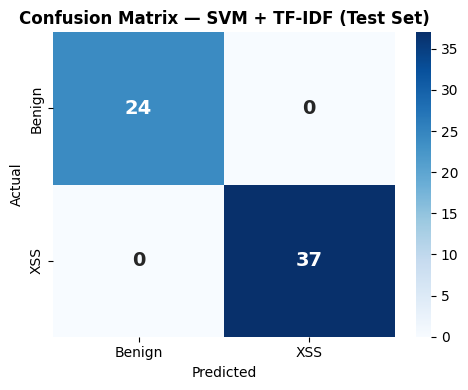


💾 Saved: svm_xss_model.pkl, tfidf_vectorizer.pkl


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

print('=' * 55)
print('Training SVM + TF-IDF...')
print('=' * 55)
start = time.time()

tfidf_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=10000,
    sublinear_tf=True,
    strip_accents='unicode'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_val_tfidf   = tfidf_vectorizer.transform(X_val_raw)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_raw)

svm_model = SVC(kernel='linear', probability=True, random_state=42, C=1.0)
svm_model.fit(X_train_tfidf, y_train_raw)
time_svm = time.time() - start

# ✅ Evaluate trên Val (để monitor) và Test (final result)
y_pred_svm_val  = svm_model.predict(X_val_tfidf)
y_pred_svm      = svm_model.predict(X_test_tfidf)
acc_svm_val     = accuracy_score(y_val_raw, y_pred_svm_val)
acc_svm         = accuracy_score(y_test_raw, y_pred_svm)

print(f'\n⏱️  Training time: {time_svm:.2f}s')
print(f'📊 Val  Accuracy:  {acc_svm_val:.4f}')
print(f'✅ Test Accuracy:  {acc_svm:.4f}  ← kết quả thật sự')
gap = abs(acc_svm_val - acc_svm)
print(f'   Val-Test gap:   {gap:.4f} {"✅ OK" if gap < 0.03 else "⚠️ Overfit?"}')

print('\n' + classification_report(
    y_test_raw, y_pred_svm,
    target_names=['Benign', 'XSS'], digits=4
))

# Confusion matrix
cm_svm = confusion_matrix(y_test_raw, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','XSS'], yticklabels=['Benign','XSS'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix — SVM + TF-IDF (Test Set)', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

# Save
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(svm_model, 'svm_xss_model.pkl')
print('\n💾 Saved: svm_xss_model.pkl, tfidf_vectorizer.pkl')

## 📊 MÔ HÌNH 2: DistilBERT

- 40% nhỏ hơn BERT gốc, 60% nhanh hơn, accuracy gần tương đương
- Hiểu context tốt hơn SVM — phù hợp obfuscated/complex XSS
- **Cần GPU** (T4 trên Colab)

**Eval strategy đúng:**
- Eval trên `val_ds` sau mỗi epoch (chọn best checkpoint)
- Early stopping nếu không cải thiện sau 2 epoch
- Test set chỉ được dùng **1 lần duy nhất** sau khi train xong


In [ ]:
import torch
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from torch.utils.data import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cpu':
    print('⚠️  Không có GPU! Training DistilBERT sẽ rất chậm (~giờ). Khuyến nghị T4 GPU.')
    print('   Vào: Runtime → Change runtime type → T4 GPU')

class XSSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts  = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), truncation=True,
            padding='max_length', max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p = precision_score(labels, preds, zero_division=0)
    r = recall_score(labels, preds, zero_division=0)
    f = f1_score(labels, preds, zero_division=0)
    a = accuracy_score(labels, preds)
    return {'accuracy': a, 'precision': p, 'recall': r, 'f1': f}

print('\nLoading DistilBERT...')
tokenizer_distil = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
model_distil = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
model_distil.to(device)

# ✅ 3 datasets riêng biệt
train_ds_distil = XSSDataset(X_train_raw, y_train_raw, tokenizer_distil)
val_ds_distil   = XSSDataset(X_val_raw,   y_val_raw,   tokenizer_distil)
test_ds_distil  = XSSDataset(X_test_raw,  y_test_raw,  tokenizer_distil)

training_args_distil = TrainingArguments(
    output_dir='./results_distil',
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    # ✅ FIX 3: transformers >=4.41 dùng 'eval_strategy' (cũ là 'evaluation_strategy')
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',    # Dùng F1 thay vì accuracy — tốt hơn cho imbalanced
    greater_is_better=True,
    learning_rate=2e-5,
    fp16=(device.type == 'cuda'),
    logging_steps=100,
    report_to='none'
)

trainer_distil = Trainer(
    model=model_distil,
    args=training_args_distil,
    train_dataset=train_ds_distil,
    eval_dataset=val_ds_distil,     # ✅ Eval trên VAL, không phải test
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('🚀 Training DistilBERT...')
trainer_distil.train()

Device: cpu
⚠️  Không có GPU! Training DistilBERT sẽ rất chậm (~giờ). Khuyến nghị T4 GPU.
   Vào: Runtime → Change runtime type → T4 GPU

Loading DistilBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=45, training_loss=0.6927119361029731, metrics={'train_runtime': 1048.7876, 'train_samples_per_second': 1.335, 'train_steps_per_second': 0.043, 'total_flos': 46363589529600.0, 'train_loss': 0.6927119361029731, 'epoch': 5.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


📊 Final evaluation trên TEST SET...



✅ DistilBERT Test Accuracy: 0.8361

              precision    recall  f1-score   support

      Benign     0.8182    0.7500    0.7826        24
         XSS     0.8462    0.8919    0.8684        37

    accuracy                         0.8361        61
   macro avg     0.8322    0.8209    0.8255        61
weighted avg     0.8351    0.8361    0.8347        61



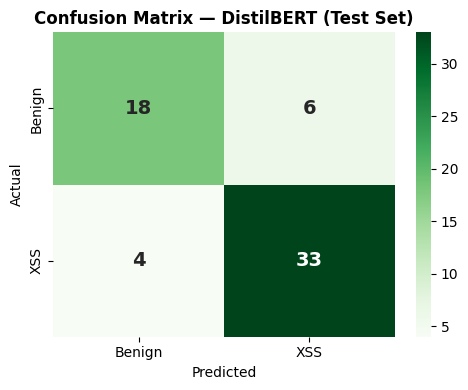

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Saved: xss_distilbert_model/


In [ ]:
# ✅ Final eval trên TEST SET — chạy đúng 1 lần sau khi train xong
print('📊 Final evaluation trên TEST SET...')
pred_output_distil = trainer_distil.predict(test_ds_distil)
y_pred_distil = np.argmax(pred_output_distil.predictions, axis=-1)
acc_distil = accuracy_score(y_test_raw, y_pred_distil)

print(f'\n✅ DistilBERT Test Accuracy: {acc_distil:.4f}')
print('\n' + classification_report(
    y_test_raw, y_pred_distil,
    target_names=['Benign', 'XSS'], digits=4
))

cm_distil = confusion_matrix(y_test_raw, y_pred_distil)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_distil, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign','XSS'], yticklabels=['Benign','XSS'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix — DistilBERT (Test Set)', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

model_distil.save_pretrained('./xss_distilbert_model')
tokenizer_distil.save_pretrained('./xss_distilbert_model')
print('💾 Saved: xss_distilbert_model/')

## 📊 MÔ HÌNH 3: PhoBERT

**Lưu ý về PhoBERT với XSS payload:**
- PhoBERT được pretrain trên tiếng Việt (VnExpress, Wikipedia VI)
- XSS payload là English/code → PhoBERT sẽ tokenize kém hơn DistilBERT với payload thuần
- **PhoBERT có lợi thế** khi input là text tiếng Việt có chứa payload nhúng bên trong
- Kết quả PhoBERT trên dataset này có thể thấp hơn hoặc tương đương DistilBERT

> Đây là điều bình thường — giữ PhoBERT để **so sánh** và rút ra kết luận trong báo cáo.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print('Loading PhoBERT...')
tokenizer_pho = AutoTokenizer.from_pretrained('vinai/phobert-base')
model_pho = AutoModelForSequenceClassification.from_pretrained(
    'vinai/phobert-base', num_labels=2
)
model_pho.to(device)

# PhoBERT dùng max_len=256 vì tokenizer của nó tạo nhiều token hơn với text Latin
train_ds_pho = XSSDataset(X_train_raw, y_train_raw, tokenizer_pho, max_len=256)
val_ds_pho   = XSSDataset(X_val_raw,   y_val_raw,   tokenizer_pho, max_len=256)
test_ds_pho  = XSSDataset(X_test_raw,  y_test_raw,  tokenizer_pho, max_len=256)

training_args_pho = TrainingArguments(
    output_dir='./results_phobert',
    num_train_epochs=5,
    per_device_train_batch_size=8,    # Nhỏ hơn vì max_len=256 dùng nhiều VRAM
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    # ✅ FIX 4: eval_strategy đúng cú pháp
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    learning_rate=2e-5,
    fp16=(device.type == 'cuda'),
    logging_steps=100,
    report_to='none'
)

trainer_pho = Trainer(
    model=model_pho,
    args=training_args_pho,
    train_dataset=train_ds_pho,
    eval_dataset=val_ds_pho,          # ✅ Eval trên VAL, không phải test
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('🚀 Training PhoBERT (chậm hơn DistilBERT ~2x)...')
trainer_pho.train()

Loading PhoBERT...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=175, training_loss=0.500596204485212, metrics={'train_runtime': 4716.59, 'train_samples_per_second': 0.297, 'train_steps_per_second': 0.037, 'total_flos': 184177738752000.0, 'train_loss': 0.500596204485212, 'epoch': 5.0})

📊 Final evaluation trên TEST SET...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ PhoBERT Test Accuracy: 0.9672

              precision    recall  f1-score   support

      Benign     0.9583    0.9583    0.9583        24
         XSS     0.9730    0.9730    0.9730        37

    accuracy                         0.9672        61
   macro avg     0.9657    0.9657    0.9657        61
weighted avg     0.9672    0.9672    0.9672        61



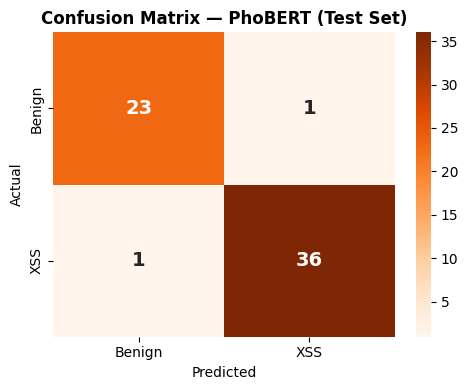

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Saved: xss_phobert_model/


In [ ]:
# ✅ Final eval trên TEST SET
print('📊 Final evaluation trên TEST SET...')
pred_output_pho = trainer_pho.predict(test_ds_pho)
y_pred_pho = np.argmax(pred_output_pho.predictions, axis=-1)
acc_pho = accuracy_score(y_test_raw, y_pred_pho)

print(f'\n✅ PhoBERT Test Accuracy: {acc_pho:.4f}')
print('\n' + classification_report(
    y_test_raw, y_pred_pho,
    target_names=['Benign', 'XSS'], digits=4
))

cm_pho = confusion_matrix(y_test_raw, y_pred_pho)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pho, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign','XSS'], yticklabels=['Benign','XSS'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix — PhoBERT (Test Set)', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

model_pho.save_pretrained('./xss_phobert_model')
tokenizer_pho.save_pretrained('./xss_phobert_model')
print('💾 Saved: xss_phobert_model/')

## 📈 SO SÁNH 3 MÔ HÌNH


📊 BẢNG SO SÁNH 3 MÔ HÌNH — Test Set (held-out)
       Model  Accuracy  Precision  Recall  F1-Score
SVM + TF-IDF    1.0000     1.0000  1.0000    1.0000
  DistilBERT    0.8361     0.8462  0.8919    0.8684
     PhoBERT    0.9672     0.9730  0.9730    0.9730


/tmp/ipykernel_311/3694935683.py:53: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_311/3694935683.py:54: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.savefig('model_comparison.png', dpi=200, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


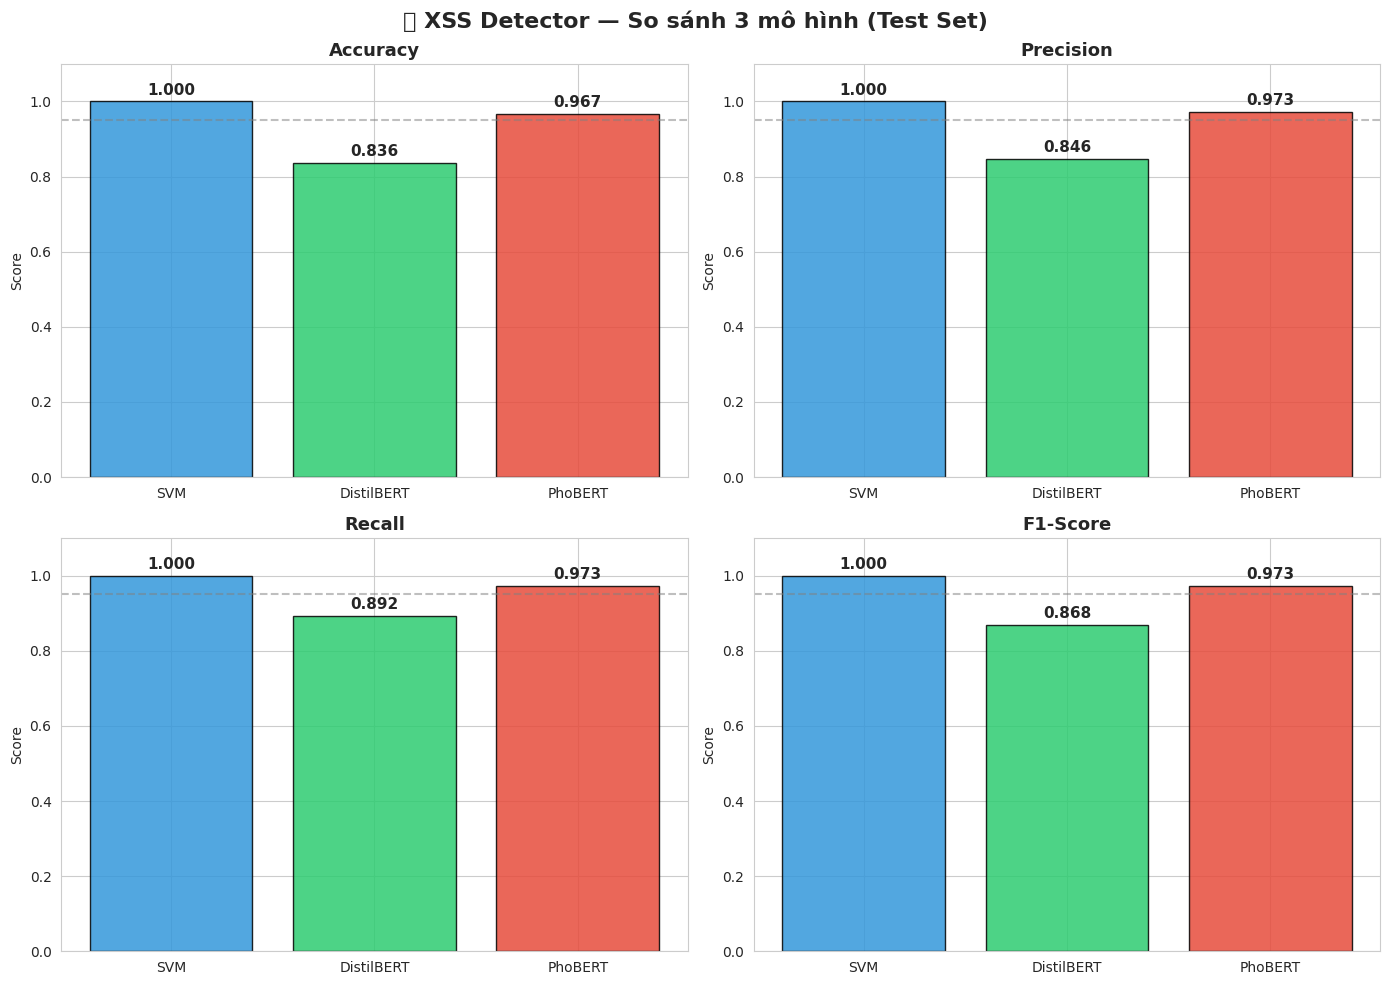

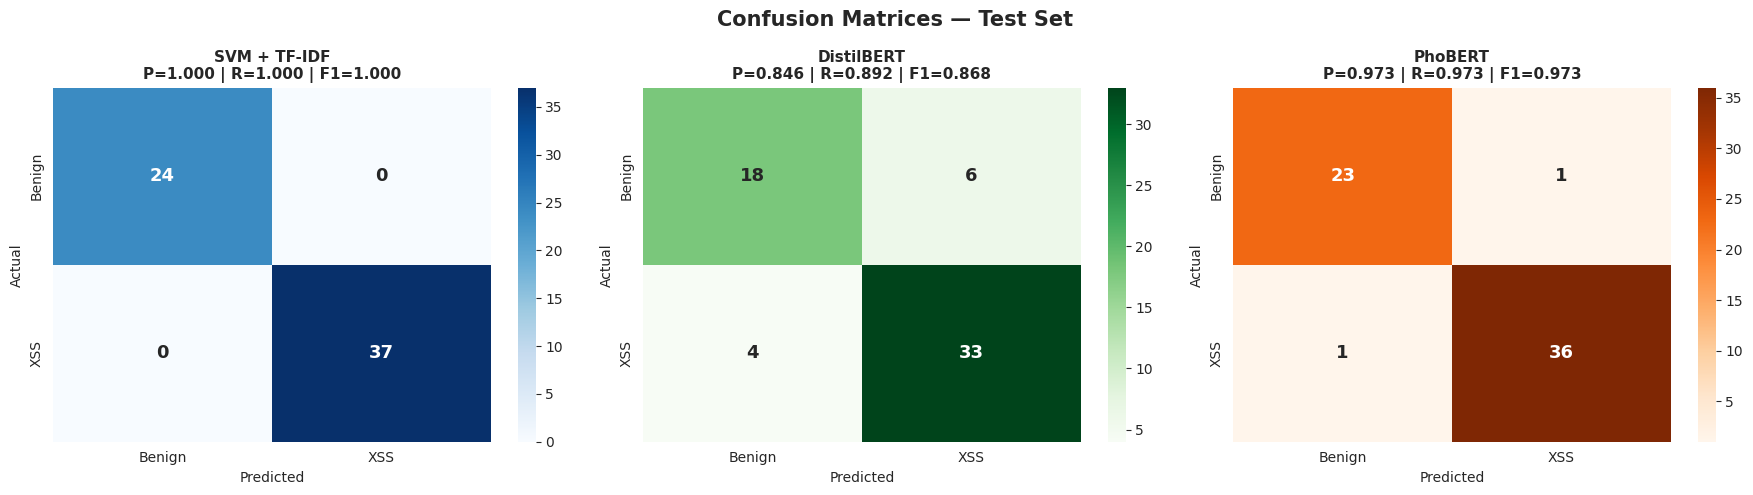

✅ Saved: model_comparison.png, confusion_matrices.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def get_metrics(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0)
    }

metrics_svm    = get_metrics(y_test_raw, y_pred_svm)
metrics_distil = get_metrics(y_test_raw, y_pred_distil)
metrics_pho    = get_metrics(y_test_raw, y_pred_pho)

comparison_df = pd.DataFrame({
    'Model':     ['SVM + TF-IDF', 'DistilBERT', 'PhoBERT'],
    'Accuracy':  [metrics_svm['accuracy'],  metrics_distil['accuracy'],  metrics_pho['accuracy']],
    'Precision': [metrics_svm['precision'], metrics_distil['precision'], metrics_pho['precision']],
    'Recall':    [metrics_svm['recall'],    metrics_distil['recall'],    metrics_pho['recall']],
    'F1-Score':  [metrics_svm['f1'],        metrics_distil['f1'],        metrics_pho['f1']],
})

print('\n' + '='*65)
print('📊 BẢNG SO SÁNH 3 MÔ HÌNH — Test Set (held-out)')
print('='*65)
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))
print('='*65)

# Vẽ biểu đồ so sánh 4 metrics
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🛡️ XSS Detector — So sánh 3 mô hình (Test Set)',
             fontsize=16, fontweight='bold')

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_keys  = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#3498db', '#2ecc71', '#e74c3c']
model_names = ['SVM', 'DistilBERT', 'PhoBERT']

for idx, (mname, mkey) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[idx // 2, idx % 2]
    vals = [metrics_svm[mkey], metrics_distil[mkey], metrics_pho[mkey]]
    bars = ax.bar(model_names, vals, color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(mname, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='0.95 threshold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# Confusion matrix 3 model
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')

for i, (name, cm, cmap) in enumerate([
    ('SVM + TF-IDF', cm_svm,    'Blues'),
    ('DistilBERT',   cm_distil, 'Greens'),
    ('PhoBERT',      cm_pho,    'Oranges'),
]):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes2[i],
                xticklabels=['Benign','XSS'], yticklabels=['Benign','XSS'],
                annot_kws={'fontsize': 13, 'fontweight': 'bold'})
    tn, fp, fn, tp = cm.ravel()
    prec   = tp/(tp+fp) if (tp+fp) else 0
    recall = tp/(tp+fn) if (tp+fn) else 0
    f1_val = 2*prec*recall/(prec+recall) if (prec+recall) else 0
    axes2[i].set_title(f'{name}\nP={prec:.3f} | R={recall:.3f} | F1={f1_val:.3f}',
                       fontsize=11, fontweight='bold')
    axes2[i].set_xlabel('Predicted'); axes2[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved: model_comparison.png, confusion_matrices.png')

## 🌐 WEB SERVICE — Flask + ngrok

Web service cho phép chọn model để predict:
- Giao diện web thân thiện, hỗ trợ tiếng Việt
- API endpoint `/predict` nhận JSON, trả JSON
- Dùng **pyngrok** (flask-ngrok đã deprecated)


In [ ]:
# ✅ FIX 5: Hướng dẫn lấy ngrok authtoken
# 1. Đăng ký miễn phí tại: https://dashboard.ngrok.com/signup
# 2. Vào: https://dashboard.ngrok.com/get-started/your-authtoken
# 3. Copy token và paste vào biến NGROK_TOKEN bên dưới

!pip install pyngrok -q

NGROK_TOKEN = '3AtkEdL03tK0yA4jmDxzBOM5wug_597AEFVu4CPjsaAwnopMq'  # ← PASTE TOKEN CỦA BẠN VÀO ĐÂY

if NGROK_TOKEN == 'YOUR_NGROK_TOKEN_HERE':
    print('⚠️  Chưa set NGROK_TOKEN!')
    print('   1. Đăng ký tại: https://dashboard.ngrok.com/signup')
    print('   2. Copy token tại: https://dashboard.ngrok.com/get-started/your-authtoken')
    print('   3. Paste vào NGROK_TOKEN = "..." ở trên rồi chạy lại cell này')
else:
    from pyngrok import ngrok, conf
    conf.get_default().auth_token = NGROK_TOKEN
    print('✅ ngrok configured!')


✅ ngrok configured!


In [ ]:
from flask import Flask, request, jsonify, render_template_string
import threading
import torch

# Load tất cả models đã train
print('Loading models...')

# SVM
import joblib
_tfidf = joblib.load('tfidf_vectorizer.pkl')
_svm   = joblib.load('svm_xss_model.pkl')

# DistilBERT
_tokenizer_distil = DistilBertTokenizerFast.from_pretrained('./xss_distilbert_model')
_model_distil = DistilBertForSequenceClassification.from_pretrained('./xss_distilbert_model')
_model_distil.to(device); _model_distil.eval()

# PhoBERT
_tokenizer_pho = AutoTokenizer.from_pretrained('./xss_phobert_model')
_model_pho = AutoModelForSequenceClassification.from_pretrained('./xss_phobert_model')
_model_pho.to(device); _model_pho.eval()

print('✅ All models loaded!')

# HTML Template — giao diện web
HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>🛡️ XSS Detector</title>
    <style>
        * { box-sizing: border-box; margin: 0; padding: 0; }
        body { font-family: 'Segoe UI', Arial, sans-serif; background: #0f0f1a;
               color: #e0e0e0; min-height: 100vh; padding: 30px 20px; }
        .container { max-width: 800px; margin: 0 auto; }
        h1 { text-align: center; font-size: 2em; color: #00d4ff;
             text-shadow: 0 0 20px rgba(0,212,255,0.5); margin-bottom: 8px; }
        .subtitle { text-align: center; color: #888; margin-bottom: 30px; font-size: 0.95em; }
        .card { background: #1a1a2e; border: 1px solid #2d2d4e;
                border-radius: 12px; padding: 25px; margin-bottom: 20px; }
        label { display: block; margin-bottom: 8px; color: #aaa; font-size: 0.9em; }
        textarea { width: 100%; height: 120px; padding: 12px;
                   background: #0d0d1a; border: 1px solid #3d3d5e;
                   border-radius: 8px; color: #e0e0e0; font-size: 14px;
                   font-family: 'Courier New', monospace; resize: vertical; }
        textarea:focus { outline: none; border-color: #00d4ff; }
        .model-select { display: flex; gap: 10px; margin: 15px 0; flex-wrap: wrap; }
        .model-btn { flex: 1; min-width: 120px; padding: 10px;
                     background: #0d0d1a; border: 2px solid #3d3d5e;
                     border-radius: 8px; color: #aaa; cursor: pointer;
                     text-align: center; transition: all 0.2s; font-size: 13px; }
        .model-btn:hover { border-color: #00d4ff; color: #00d4ff; }
        .model-btn.active { border-color: #00d4ff; color: #00d4ff;
                            background: rgba(0,212,255,0.1); }
        .detect-btn { width: 100%; padding: 14px; background: linear-gradient(135deg, #00d4ff, #0066cc);
                      border: none; border-radius: 8px; color: white; font-size: 16px;
                      font-weight: bold; cursor: pointer; margin-top: 10px;
                      transition: opacity 0.2s; }
        .detect-btn:hover { opacity: 0.85; }
        .detect-btn:disabled { opacity: 0.5; cursor: not-allowed; }
        .result { display: none; border-radius: 10px; padding: 20px; margin-top: 20px; }
        .result.xss { background: rgba(231,76,60,0.15); border: 2px solid #e74c3c; }
        .result.benign { background: rgba(39,174,96,0.15); border: 2px solid #27ae60; }
        .result-label { font-size: 1.6em; font-weight: bold; margin-bottom: 10px; }
        .result.xss .result-label { color: #e74c3c; }
        .result.benign .result-label { color: #27ae60; }
        .confidence-bar { background: #0d0d1a; border-radius: 20px;
                          height: 10px; margin: 10px 0; overflow: hidden; }
        .confidence-fill { height: 100%; border-radius: 20px;
                           transition: width 0.5s ease; }
        .xss .confidence-fill { background: linear-gradient(90deg, #e74c3c, #c0392b); }
        .benign .confidence-fill { background: linear-gradient(90deg, #27ae60, #1e8449); }
        .meta { color: #888; font-size: 0.85em; margin-top: 10px; }
        .examples { display: flex; gap: 8px; flex-wrap: wrap; margin-top: 10px; }
        .example-chip { padding: 5px 12px; background: #0d0d1a;
                        border: 1px solid #3d3d5e; border-radius: 20px;
                        font-size: 12px; cursor: pointer; color: #aaa;
                        font-family: 'Courier New', monospace; transition: all 0.2s; }
        .example-chip:hover { border-color: #00d4ff; color: #00d4ff; }
        .loading { display: none; text-align: center; padding: 20px;
                   color: #00d4ff; font-style: italic; }
    </style>
</head>
<body>
<div class="container">
    <h1>🛡️ XSS Payload Detector</h1>
    <p class="subtitle">Phân loại XSS payload bằng NLP — SVM | DistilBERT | PhoBERT</p>

    <div class="card">
        <label>📌 Chọn mô hình:</label>
        <div class="model-select">
            <div class="model-btn active" onclick="selectModel('svm', this)">⚡ SVM + TF-IDF<br><small>Nhanh nhất</small></div>
            <div class="model-btn" onclick="selectModel('distilbert', this)">🤖 DistilBERT<br><small>Cân bằng</small></div>
            <div class="model-btn" onclick="selectModel('phobert', this)">🇻🇳 PhoBERT<br><small>Tiếng Việt</small></div>
        </div>

        <label>💬 Nhập payload hoặc text cần kiểm tra:</label>
        <textarea id="payload" placeholder="Ví dụ: &lt;script&gt;alert('XSS')&lt;/script&gt;"></textarea>

        <label>🧪 Thử nhanh:</label>
        <div class="examples">
            <span class="example-chip" onclick="setExample(this.textContent)">&lt;script&gt;alert(1)&lt;/script&gt;</span>
            <span class="example-chip" onclick="setExample(this.textContent)">&lt;img src=x onerror=alert(1)&gt;</span>
            <span class="example-chip" onclick="setExample(this.textContent)">javascript:alert('XSS')</span>
            <span class="example-chip" onclick="setExample(this.textContent)">Xin chào, tôi đang tìm kiếm laptop</span>
            <span class="example-chip" onclick="setExample(this.textContent)">SELECT * FROM users WHERE id=1</span>
        </div>

        <button class="detect-btn" id="detectBtn" onclick="detectXSS()">🔍 PHÁT HIỆN XSS</button>
    </div>

    <div class="loading" id="loading">⏳ Đang phân tích...</div>

    <div class="result" id="result">
        <div class="result-label" id="resultLabel"></div>
        <div>Độ tin cậy: <strong id="confText"></strong></div>
        <div class="confidence-bar"><div class="confidence-fill" id="confBar"></div></div>
        <div class="meta" id="resultMeta"></div>
    </div>
</div>

<script>
let selectedModel = 'svm';

function selectModel(model, el) {
    selectedModel = model;
    document.querySelectorAll('.model-btn').forEach(b => b.classList.remove('active'));
    el.classList.add('active');
}

function setExample(text) {
    document.getElementById('payload').value = text;
}

function detectXSS() {
    const payload = document.getElementById('payload').value.trim();
    if (!payload) { alert('Vui lòng nhập payload!'); return; }

    const btn = document.getElementById('detectBtn');
    btn.disabled = true;
    document.getElementById('loading').style.display = 'block';
    document.getElementById('result').style.display = 'none';

    fetch('/predict', {
        method: 'POST',
        headers: {'Content-Type': 'application/json'},
        body: JSON.stringify({payload: payload, model: selectedModel})
    })
    .then(r => r.json())
    .then(data => {
        document.getElementById('loading').style.display = 'none';
        btn.disabled = false;

        const resultDiv = document.getElementById('result');
        const isXSS = data.prediction === 'XSS';
        resultDiv.className = 'result ' + (isXSS ? 'xss' : 'benign');
        document.getElementById('resultLabel').textContent =
            isXSS ? '🚨 PHÁT HIỆN XSS!' : '✅ AN TOÀN (Benign)';
        const conf = (data.confidence * 100).toFixed(2);
        document.getElementById('confText').textContent = conf + '%';
        document.getElementById('confBar').style.width = conf + '%';
        document.getElementById('resultMeta').innerHTML =
            '<b>Mô hình:</b> ' + data.model + ' &nbsp;|&nbsp; '
            + '<b>Input:</b> ' + payload.substring(0, 80) + (payload.length > 80 ? '...' : '');
        resultDiv.style.display = 'block';
    })
    .catch(err => {
        document.getElementById('loading').style.display = 'none';
        btn.disabled = false;
        alert('Lỗi: ' + err);
    });
}

document.getElementById('payload').addEventListener('keydown', e => {
    if (e.ctrlKey && e.key === 'Enter') detectXSS();
});
</script>
</body></html>
"""

# Flask app
app = Flask(__name__)

@app.route('/')
def home():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data    = request.get_json()
        text    = data.get('payload', '')
        model_choice = data.get('model', 'svm')

        cleaned = preprocess_text(text)

        if model_choice == 'svm':
            vec   = _tfidf.transform([cleaned])
            pred  = _svm.predict(vec)[0]
            prob  = _svm.predict_proba(vec)[0][pred]
            mname = 'SVM + TF-IDF'

        elif model_choice == 'distilbert':
            inputs = _tokenizer_distil(cleaned, return_tensors='pt',
                                       truncation=True, padding=True,
                                       max_length=128).to(device)
            with torch.no_grad():
                logits = _model_distil(**inputs).logits
                probs  = torch.softmax(logits, dim=-1)[0]
                pred   = torch.argmax(probs).item()
                prob   = probs[pred].item()
            mname = 'DistilBERT'

        elif model_choice == 'phobert':
            inputs = _tokenizer_pho(cleaned, return_tensors='pt',
                                    truncation=True, padding=True,
                                    max_length=256).to(device)
            with torch.no_grad():
                logits = _model_pho(**inputs).logits
                probs  = torch.softmax(logits, dim=-1)[0]
                pred   = torch.argmax(probs).item()
                prob   = probs[pred].item()
            mname = 'PhoBERT'

        else:
            return jsonify({'error': 'Unknown model'}), 400

        return jsonify({
            'payload':    text,
            'prediction': 'XSS' if pred == 1 else 'Benign',
            'confidence': round(float(prob), 4),
            'model':      mname
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/health')
def health():
    return jsonify({'status': 'ok', 'models': ['svm', 'distilbert', 'phobert']})

print('✅ Flask app ready!')

Loading models...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ All models loaded!
✅ Flask app ready!


In [ ]:
# Khởi động server
from pyngrok import ngrok

# Tắt tunnel cũ nếu có
ngrok.kill()

# Tạo public URL
public_url = ngrok.connect(5000)
print('\n' + '='*55)
print('🚀 XSS Detector Web Service đang chạy!')
print(f'🌐 Public URL: {public_url}')
print('='*55)
print('📌 Ctrl+Enter trong textarea để detect nhanh')
print('📌 Endpoint API: POST /predict')
print('   Body: {"payload": "...", "model": "svm|distilbert|phobert"}')
print('\n⚠️  Giữ cell này chạy để server hoạt động')
print('   Để dừng: Runtime → Interrupt execution')

app.run(port=5000)


🚀 XSS Detector Web Service đang chạy!
🌐 Public URL: NgrokTunnel: "https://homogamous-tamest-dorethea.ngrok-free.dev" -> "http://localhost:5000"
📌 Ctrl+Enter trong textarea để detect nhanh
📌 Endpoint API: POST /predict
   Body: {"payload": "...", "model": "svm|distilbert|phobert"}

⚠️  Giữ cell này chạy để server hoạt động
   Để dừng: Runtime → Interrupt execution
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:08] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:09] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:16] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:20] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:20] "GET /x HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:30] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:43] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:47] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:51] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Mar/2026 17:27:55] "POST /predict HTTP

## 💾 Download tất cả models & visualizations

In [ ]:
# ✅ FIX 6: Kiểm tra môi trường trước khi import google.colab
import os

!zip -r xss_detector_full.zip \
    svm_xss_model.pkl tfidf_vectorizer.pkl \
    xss_distilbert_model/ xss_phobert_model/ \
    model_comparison.png confusion_matrices.png

# Download tự động nếu đang chạy trên Google Colab
try:
    from google.colab import files
    files.download('xss_detector_full.zip')
    print('✅ Downloaded xss_detector_full.zip')
except ImportError:
    print('✅ File saved: xss_detector_full.zip')
    print('   (Chạy trên local → tải file thủ công từ thư mục hiện tại)')


  adding: svm_xss_model.pkl (deflated 64%)
  adding: tfidf_vectorizer.pkl (deflated 79%)
  adding: xss_distilbert_model/ (stored 0%)
  adding: xss_distilbert_model/tokenizer.json (deflated 71%)
  adding: xss_distilbert_model/config.json (deflated 49%)
  adding: xss_distilbert_model/model.safetensors (deflated 8%)
  adding: xss_distilbert_model/tokenizer_config.json (deflated 42%)
  adding: xss_phobert_model/ (stored 0%)
  adding: xss_phobert_model/added_tokens.json (stored 0%)
  adding: xss_phobert_model/bpe.codes (deflated 59%)
  adding: xss_phobert_model/config.json (deflated 52%)
  adding: xss_phobert_model/model.safetensors (deflated 19%)
  adding: xss_phobert_model/vocab.txt (deflated 55%)
  adding: xss_phobert_model/tokenizer_config.json (deflated 76%)
  adding: model_comparison.png (deflated 27%)
  adding: confusion_matrices.png (deflated 21%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded xss_detector_full.zip
